# Assignment 4

Before working on this assignment please read these instructions fully. In the submission area, you will notice that you can click the link to **Preview the Grading** for each step of the assignment. This is the criteria that will be used for peer grading. Please familiarize yourself with the criteria before beginning the assignment.

This assignment requires that you find **at least two datasets** on the web which are related, and that you visualize these datasets to answer the assignment question. You are free to utilize datasets with any location or domain, the usage of **Ann Arbor sports and athletics** datasets in the example is just a suggestion.

You are welcome to choose datasets at your discretion, but keep in mind **they will be shared with your peers**, so choose appropriate datasets. Sensitive, confidential, illicit, and proprietary materials are not good choices for datasets for this assignment. You are welcome to upload datasets of your own as well, and link to them using a third party repository such as github, pastebin, etc. Please be aware of the Coursera terms of service with respect to intellectual property.

Also, you are welcome to preserve data in its original language, but for the purposes of grading you should provide english translations. You are welcome to provide multiple visuals in different languages if you would like!

As this assignment is for the whole course, you must incorporate principles discussed in the first week, such as having as high data-ink ratio (Tufte) and aligning with Cairo’s principles of truth, beauty, function, and insight.

Here are the assignment instructions:

 * You must state a question you are seeking to answer with your visualizations.
 * You must provide at least two links to available datasets. These could be links to files such as CSV or Excel files, or links to websites which might have data in tabular form, such as Wikipedia pages.
 * You must upload an image which addresses the research question you stated. In addition to addressing the question, this visual should follow Cairo's principles of truthfulness, functionality, beauty, and insightfulness.
 * You must contribute a short (1-2 paragraph) written justification of how your visualization addresses your stated research question.

## Tips
* Wikipedia is an excellent source of data, and I strongly encourage you to explore it for new data sources.
* Many governments run open data initiatives at the city, region, and country levels, and these are wonderful resources for localized data sources.
* Several international agencies, such as the [United Nations](http://data.un.org/), the [World Bank](http://data.worldbank.org/), the [Global Open Data Index](http://index.okfn.org/place/) are other great places to look for data.
* This assignment requires you to convert and clean datafiles. Check out the discussion forums for tips on how to do this from various sources, and share your successes with your fellow students!

## Example
Looking for an example? Here's what our course assistant put together as an example! [Example Solution File](./readonly/Assignment4_example.pdf)

# Visualization Project:
Question: How does frog identifications vary through the year according to their habitat?

In [1]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colormaps
import seaborn as sns
from matplotlib.widgets import RadioButtons, Button

## Data loading and cleaning

In [2]:
def amphiBIO():
# Reads and cleans data from amphiBIO dataset
    df = pd.read_csv('./assets/AmphiBIO_v1.csv',encoding = "ISO-8859-1",
                    index_col = 'Species')
    return df

In [3]:
def FrogID():
# Reads and cleans data from FrogID6 dataset.
    df = pd.read_csv('./assets/FrogID6_final_dataset.csv',
                    usecols = ['decimalLatitude','decimalLongitude','scientificName','eventDate'],
                    index_col='scientificName')
    # Change scientific names to match amphiBIO
    df.rename(index={'Philoria sphagnicola':'Philoria sphagnicolus',
                    'Neobatrachus sudellae':'Neobatrachus sudelli'},inplace=True)
    # Combine eventDate and eventTime and format as datetime:
    df['eventDate']=pd.to_datetime(df['eventDate'])
    df.index.names=['Species']
    return df

In [4]:
def getFrogData():
# Reads amphiBIO and FrogID6 datasets
# Returns a merger of both dataFrames
    amph = amphiBIO()
    frog = FrogID()
    df = pd.merge(frog,amph,how='left',left_index=True,right_index=True)
    df['eventCount']=0 # Initialized to zero, to be used later
    return df

## Data plotting

In [5]:
def getDate(row):
    return pd.to_datetime(f"{int(row['M'])}-{int(row['D'])}-2024")
    
def getDailyAverages(df,start_year,end_year):
# Extracts relevant date data, and groups the same dates together
    date_mask = (df['eventDate'].dt.year>=start_year) & (df['eventDate'].dt.year<end_year)
    df['M'] = df['eventDate'].dt.month 
    df['D'] = df['eventDate'].dt.day 
    df = df[date_mask].copy()
    df = df.groupby(['M','D']).agg({'eventCount':['min','median','max']})
    df.columns = ['min','med','max']
    df = df.reset_index()
    df['eventDate']= df.apply(getDate,axis=1)
    return df
    
def drawTimeSeries(axis,timeData,start_year,end_year,color):
# Draws a timeline of daily averages between start_year and end_year, with shading to indicate 
# maxima and minima over time
    axis.cla()
    df = timeData[['eventDate','eventCount']].groupby('eventDate').agg({'eventCount':'count'}).reset_index()
    df = getDailyAverages(df,start_year,end_year)
    sns.lineplot(x='eventDate', y='min', data=df,alpha=0,ax=axis)
    sns.lineplot(x='eventDate', y='max', data=df,alpha=0,ax=axis)
    plot = sns.lineplot(x='eventDate', y='med', data=df,ax=axis,color=color)
    line = plot.get_lines()
    axis.fill_between(line[0].get_xdata(), line[0].get_ydata(), line[1].get_ydata(), color=color, alpha=.25)
    m,M=df['min'].min(),df['max'].max()
    return (0,M)


In [6]:
def figFormatting(extrema,frogs):
# Sets formating for all subfigures
    start=pd.to_datetime(f'01-01-2024')
    end=pd.to_datetime(f'12-31-2024')
    fig = plt.gcf()
    for idx,ax in enumerate(fig.get_axes()):
        ax.set_ylabel(frogs[idx],rotation=0,labelpad=60)
        ax.xaxis.label.set_color('slategray')
        ax.yaxis.label.set_color('slategray')
        ax.set_xlim(start,end) 
        
        ax.set_yticks(extrema[idx])  
        ax.tick_params(axis='both', colors='slategray')
        
        ax.spines['top'].set_visible(False);
        ax.spines['right'].set_visible(False);

        # Date formatting on x-axis for last subplots
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1,13,1)));
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));
        ax.tick_params(axis='x', labelrotation=90)
    
    # Colors
    ax.yaxis.label.set_color('slategray')
    plt.xlabel("Day of the Year")
    
    # Reduce space between subplots
    plt.subplots_adjust(left=0.2, right=1, 
                    top=1, bottom=0, 
                    wspace=0.4, hspace=0.25)

def drawFigureSet(data,dfs):
# Input: df and array of tuples (data_mask,color)
# Output n graphs stacked vertically, showing the development between 2017 and 2024 
#    of observations satisfying the given masks.
    global fig
    ext=[]
    if (len(dfs)==1):
        mask,color=dfs[0]
        v = drawTimeSeries(ax,data[mask],2017,2024,color)
        ext.append(v);
    else:
        i=0
        for idx,(mask,color) in enumerate(dfs):
            ax[idx].cla()
            v = drawTimeSeries(ax[idx],data[mask],2017,2024,color);
            ext.append(v); 
    
    plt.suptitle('Daily Frog identifications for the 5 most identified frogs, by Habitat')
    return ext

In [7]:
def getTop5 (df):
    df = df.groupby('Species').agg({'eventCount':'count'}).sort_values('eventCount',ascending=False)
    return df.index[:5]

    
def drawPerHabitat(habitat):
# Prints timelines for the top5 froms of the given habitat
# 'Fos' for fosoreal (burrowing frogs)
# 'Terr' for terrestreal (land frogs)
# 'Aqu' for aquatic (water frogs)
# 'Arb' for arboreal (tree frogs)
    df = getFrogData().reset_index()
    frogs = getTop5(df[df[habitat]==1])
    cmap = colormaps['viridis']
    s = []
    for idx,frog in enumerate(frogs):
        s.append( (df['Species']==frog , cmap(idx/len(frogs))) ) 
    ext = drawFigureSet(df,s);
    figFormatting(ext,frogs)
    return

## Interactivity functions

In [8]:
def exit(event):
# Closes the widget
    global fig
    plt.clf()
    plt.close()

In [9]:
def switchFrogs(label):
    if label == 'Burrowing frogs':
        drawPerHabitat('Fos')
    elif label == 'Terrestrial frogs':
        drawPerHabitat('Ter')
    elif label == 'Aquatic frogs':
        drawPerHabitat('Aqu')
    elif label == 'Tree frogs':
        drawPerHabitat('Arb')
    return

# Animation Code

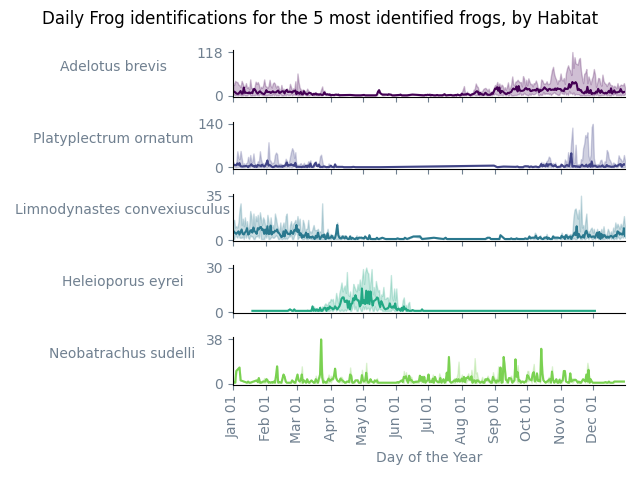

0

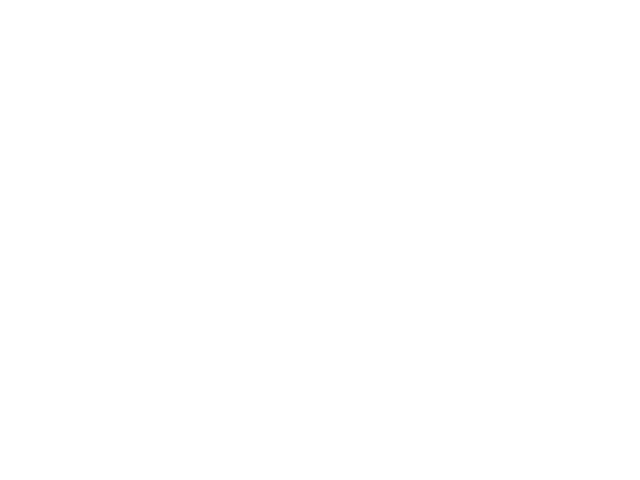

In [10]:
plt.figure()
fig,ax = plt.subplots(5,1,sharex=True)
drawPerHabitat('Fos')

plt.tight_layout()
plt.show();

# Exit Button
axB = plt.axes([0.85, 0, 0.1, 0.04])
buttonE = Button(axB, 'Exit', color='lightsteelblue', hovercolor='slategray')
buttonE.on_clicked(exit)

# Radio button for Habitat selection
axR = plt.axes([0.01, 0.01, 0.25, 0.2])
rbuttons = RadioButtons(axR, ('Burrowing frogs','Terrestrial frogs', 
                                  'Aquatic frogs','Tree frogs'),
                            activecolor='slategray')
rbuttons.on_clicked(switchFrogs)
